In [1]:
#use the trained model to predict the amount of tip paid for taxi drivers.
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

In [17]:
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [18]:
#In this section you will read the dataset in a Pandas dataframe and visualize its content. You will also look at some data statistics.
# read the input data
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
raw_data = pd.read_csv(url)
raw_data


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41197,2,1,16.94,2,1,132,164,1,70.0,0.5,6.94,1,5.00
41198,2,4,19.83,2,1,132,166,1,70.0,0.5,6.94,1,8.00
41199,2,1,17.31,2,1,132,137,1,70.0,0.5,6.94,1,8.00
41200,2,1,17.28,2,1,132,233,1,70.0,0.5,6.94,1,16.19


'\nThis shows us that the input features payment_type, VendorID, store_and_fwd_flag \nand improvement_surcharge have little to no correlation \nwith the target variable.\n'

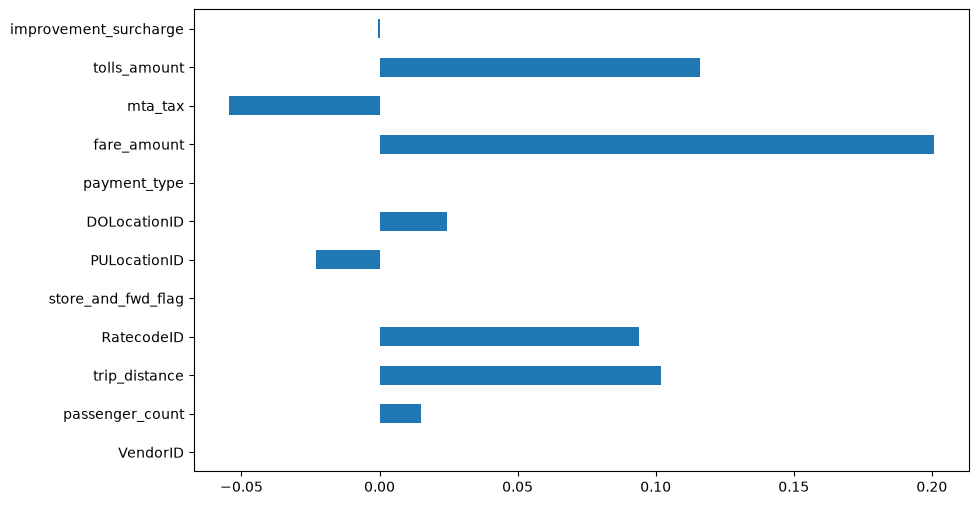

In [19]:
'''
لفهم مجموعة البيانات بشكل أفضل، دعنا نرسم بيانيًا مدى ارتباط المتغير المستهدف بالمتغيرات المدخلة
'''
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')
correlation_values.plot(kind='barh', figsize=(10, 6))

'''
This shows us that the input features payment_type, VendorID, store_and_fwd_flag 
and improvement_surcharge have little to no correlation 
with the target variable.
'''


In [20]:
#Data Processing 
#prepare the data for training by applying normalization to the input features.

# extract the labels from the dataframe
y = raw_data[['tip_amount']].values.astype('float32')

# drop the target variable from the feature matrix
proc_data = raw_data.drop(['tip_amount'], axis=1)

# get the feature matrix used for training
X = proc_data.values

# normalize the feature matrix
X = normalize(X, axis=1, norm='l1', copy=False)

In [21]:
#Dataset Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [22]:
#Build a Decision Tree Regressor model with Scikit-Learn

# import the Decision Tree Regression Model from scikit-learn
from sklearn.tree import DecisionTreeRegressor

# for reproducible output across multiple function calls, set random_state to a given integer value
dt_reg = DecisionTreeRegressor(criterion = 'squared_error',
                               max_depth=8, 
                               random_state=35)

In [23]:
dt_reg.fit(X_train, y_train) #train the model using fit

DecisionTreeRegressor(max_depth=8, random_state=35)

In [25]:
'''
Evaluate the Scikit-Learn and Snap ML Decision Tree Regressor Models

To evaluate our dataset we will use the score method of the DecisionTreeRegressor object providing our testing data, this number is the 
 value which indicates the coefficient of determination. We will also evaluate the Mean Squared Error MSE
 of the regression output with respect to the test set target values. High R^2 and low MSE
 values are expected from a good regression model.


 Note that: if the model gives a negative value of R^2, this indicates that
 the prediction model created does a very poor job of predicting the values on a test set.

'''

'\nEvaluate the Scikit-Learn and Snap ML Decision Tree Regressor Models\n\nTo evaluate our dataset we will use the score method of the DecisionTreeRegressor object providing our testing data, this number is the \n value which indicates the coefficient of determination. We will also evaluate the Mean Squared Error MSE\n of the regression output with respect to the test set target values. High R^2 and low MSE\n values are expected from a good regression model.\n\n\n Note that: if the model gives a negative value of R^2, this indicates that\n the prediction model created does a very poor job of predicting the values on a test set.\n\n'

In [26]:
# run inference using the sklearn model
y_pred = dt_reg.predict(X_test)

# evaluate mean squared error on the test dataset
mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(mse_score))

r2_score = dt_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 24.555
R^2 score : 0.028


Top 3 features affecting tip amount:
fare_amount      0.200638
tolls_amount     0.116172
trip_distance    0.101819
Name: tip_amount, dtype: float64


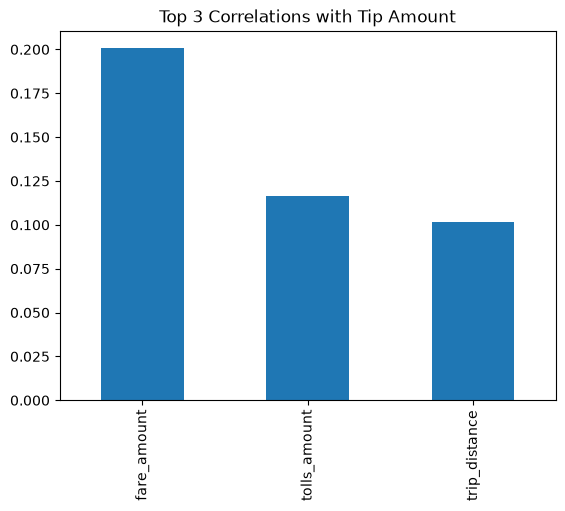

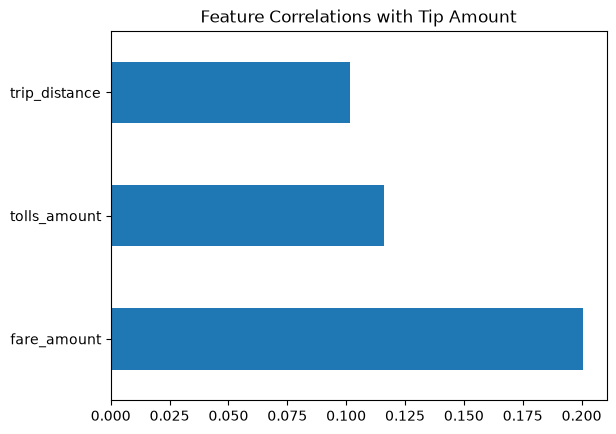

'\nAs is evident from the output, Fare amount, toll amount and trip distance\nare the top features affecting the tip amount, which make logical sense.\n'

In [31]:
# Identifying the top 3 features with the most effect on the tip_amount.
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')
# Store the top 3 correlations in a variable
top_3_correlations = abs(correlation_values).sort_values(ascending=False)[:3]

# Option 1: Display as a formatted string
print("Top 3 features affecting tip amount:")
print(correlation_values[top_3_correlations.index])

# Option 2: Create a bar plot visualization
import matplotlib.pyplot as plt
correlation_values[top_3_correlations.index].plot(kind='bar', title='Top 3 Correlations with Tip Amount')
plt.show()

# Option 3: Display as a DataFrame for better formatting
import pandas as pd
pd.DataFrame({
    'Feature': top_3_correlations.index,
    'Correlation': correlation_values[top_3_correlations.index].values
})

# Option 4: Create a horizontal bar chart
correlation_values[top_3_correlations.index].plot(kind='barh', title='Feature Correlations with Tip Amount')
plt.show()

'''
As is evident from the output, Fare amount, toll amount and trip distance
are the top features affecting the tip amount, which make logical sense.
'''

In [ ]:
'''
 Since we identified 4 features which are not correlated with the target 
 variable, try removing these variables from the input set and see the effect on the 
 MSE and R^2 value.
'''
raw_data = raw_data.drop(['payment_type', 'VendorID', 'store_and_fwd_flag',
                          'improvement_surcharge'], axis=1)


In [ ]:
#the effect of decreasing the max_depth parameter to 4 on the MSE and R^2 values.

